In [1]:
# ═══════════════════════════════════════════════════════
# CELDA 1: Instalación e Imports
# ═══════════════════════════════════════════════════════
!pip install numpy scikit-learn tensorflow matplotlib seaborn -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, hamming_loss, multilabel_confusion_matrix)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

FINGER_NAMES = ["Pulgar", "Índice", "Medio", "Anular", "Meñique"]

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ═══════════════════════════════════════════════════════
# CELDA 2: Carga del Dataset
# ═══════════════════════════════════════════════════════
import gdown

if not os.path.exists("/content/X.npy"):
    gdown.download(
        "https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv",
        "/content/X.npy", quiet=False
    )
if not os.path.exists("/content/Y.npy"):
    gdown.download(
        "https://drive.google.com/uc?id=1bGphucb5oTgLkYT2e9UB4ToaapvhKhhw",
        "/content/Y.npy", quiet=False
    )

X_full  = np.load("/content/X.npy", mmap_mode='r')
Y_raw   = np.load("/content/Y.npy", allow_pickle=True)

labels_str = Y_raw.reshape(-1).astype(str)

print("X_full shape :", X_full.shape)
print("Clases únicas:", np.unique(labels_str))

Downloading...
From (original): https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv
From (redirected): https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv&confirm=t&uuid=733b04e6-b692-4cce-9b23-6a5cecb096a6
To: /content/X.npy
100%|██████████| 4.48G/4.48G [01:10<00:00, 63.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bGphucb5oTgLkYT2e9UB4ToaapvhKhhw
To: /content/Y.npy
100%|██████████| 1.55M/1.55M [00:00<00:00, 165MB/s]

X_full shape : (22801, 128, 128, 3)
Clases únicas: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'NULL' 'a' 'b' 'bye' 'c' 'd' 'e'
 'good' 'good morning' 'hello' 'little bit' 'no' 'pardon' 'please'
 'project' 'whats up' 'yes']


In [3]:
# ═══════════════════════════════════════════════════════
# CELDA 3: Filtrar dígitos y crear etiquetas multi-etiqueta
# ═══════════════════════════════════════════════════════

# Mapa de dedos extendidos por dígito ASL
# Orden: [pulgar, índice, medio, anular, meñique]
LABEL_TO_FINGERS = {
    "0": [0, 0, 0, 0, 0],
    "1": [0, 1, 0, 0, 0],
    "2": [0, 1, 1, 0, 0],
    "3": [1, 1, 1, 0, 0],
    "4": [0, 1, 1, 1, 1],
    "5": [1, 1, 1, 1, 1],
    "6": [1, 0, 0, 0, 1],
    "7": [1, 0, 0, 1, 0],
    "8": [1, 0, 1, 0, 0],
    "9": [1, 1, 0, 0, 0],
}

digit_labels = list(LABEL_TO_FINGERS.keys())
mask_digits  = np.isin(labels_str, digit_labels)
indices_digits = np.where(mask_digits)[0]
y_digits_str   = labels_str[mask_digits]

# Crear Y multi-etiqueta (N, 5) float32
Y_fingers = np.array([LABEL_TO_FINGERS[l] for l in y_digits_str], dtype=np.float32)

img_h = X_full.shape[1]
img_w = X_full.shape[2]
num_channels = X_full.shape[3] if X_full.ndim == 4 else 1

print(f"Muestras de dígitos: {len(indices_digits)}")
print(f"Shape Y_fingers: {Y_fingers.shape}  (multi-etiqueta, 5 dedos)")
print(f"Distribución de dígitos: { {d: (y_digits_str==d).sum() for d in digit_labels} }")

# Split 70/15/15 estratificado por dígito
idx_all = np.arange(len(indices_digits))
idx_tv, idx_test, Y_tv, Y_test, y_tv_str, y_test_str = train_test_split(
    idx_all, Y_fingers, y_digits_str,
    test_size=0.15, random_state=42, stratify=y_digits_str
)
idx_train, idx_val, Y_train, Y_val, y_train_str, y_val_str = train_test_split(
    idx_tv, Y_tv, y_tv_str,
    test_size=0.176, random_state=42, stratify=y_tv_str
)

# Mapear a los índices reales del mmap
real_idx_train = indices_digits[idx_train]
real_idx_val   = indices_digits[idx_val]
real_idx_test  = indices_digits[idx_test]

print(f"\nTrain: {len(real_idx_train)} | Val: {len(real_idx_val)} | Test: {len(real_idx_test)}")

Muestras de dígitos: 8650
Shape Y_fingers: (8650, 5)  (multi-etiqueta, 5 dedos)
Distribución de dígitos: {'0': np.int64(866), '1': np.int64(865), '2': np.int64(865), '3': np.int64(865), '4': np.int64(864), '5': np.int64(865), '6': np.int64(865), '7': np.int64(865), '8': np.int64(865), '9': np.int64(865)}

Train: 6058 | Val: 1294 | Test: 1298


In [4]:
# ═══════════════════════════════════════════════════════
# CELDA 4: Generador de batches para CNN (sin explotar RAM)
# ═══════════════════════════════════════════════════════
class FingerBatchGenerator(keras.utils.Sequence):
    def __init__(self, X_mmap, real_indices, labels, batch_size=32, augment=False):
        self.X       = X_mmap
        self.idx     = real_indices
        self.labels  = labels
        self.bs      = batch_size
        self.augment = augment

    def __len__(self):
        return int(np.ceil(len(self.idx) / self.bs))

    def __getitem__(self, i):
        batch_real_idx = self.idx[i*self.bs:(i+1)*self.bs]
        imgs = np.array(self.X[batch_real_idx], dtype=np.float32)
        if imgs.max() > 1.5:
            imgs /= 255.0
        if imgs.ndim == 3:
            imgs = imgs[..., np.newaxis]
        if self.augment:
            imgs = self._augment(imgs)
        return imgs, self.labels[i*self.bs:(i+1)*self.bs]

    def _augment(self, imgs):
        # Flip horizontal
        mask = np.random.rand(len(imgs)) > 0.5
        imgs[mask] = imgs[mask, :, ::-1, :]
        # Brillo
        brightness = np.random.uniform(0.8, 1.2, (len(imgs), 1, 1, 1))
        imgs = np.clip(imgs * brightness, 0, 1)
        return imgs

BATCH_SIZE = 32
train_gen = FingerBatchGenerator(X_full, real_idx_train, Y_train, BATCH_SIZE, augment=True)
val_gen   = FingerBatchGenerator(X_full, real_idx_val,   Y_val,   BATCH_SIZE, augment=False)
test_gen  = FingerBatchGenerator(X_full, real_idx_test,  Y_test,  BATCH_SIZE, augment=False)

print(f"Batches — Train: {len(train_gen)} | Val: {len(val_gen)} | Test: {len(test_gen)}")

Batches — Train: 190 | Val: 41 | Test: 41


In [5]:
# ═══════════════════════════════════════════════════════
# CELDA 5: Selección de métricas
# ═══════════════════════════════════════════════════════
# ─── JUSTIFICACIÓN ───────────────────────────────────
# Problema: Clasificación MULTI-ETIQUETA (5 salidas binarias independientes)
#
# MÉTRICA DE OPTIMIZACIÓN (loss que minimiza Keras internamente):
#   → binary_crossentropy
#     Razón: cada dedo es una clasificación binaria independiente.
#     Mide la divergencia de cada neurona sigmoide por separado.
#     Más apropiado que categorical_crossentropy (que supone clases mutuamente excluyentes).
#
# MÉTRICA DE SATISFACCIÓN (criterio de calidad del modelo):
#   → Primary:   Exact Match Ratio  — los 5 dedos correctos simultáneamente (más exigente)
#   → Secondary: Hamming Accuracy   — porcentaje de dedos individuales correctos
#   → Additional: F1-score por dedo — balance precisión/recall por dedo individualmente
#
# CRITERIO DE ÉXITO:
#   Exact Match    >= 0.85  →  modelo aceptable
#   Exact Match    >= 0.92  →  modelo robusto
#   Hamming Acc    >= 0.95  →  esperado dado que cada bit tiene alta probabilidad base
# ──────────────────────────────────────────────────────

OPTIMIZER_LOSS        = "binary_crossentropy"
THRESHOLD_ACCEPTABLE  = 0.85
THRESHOLD_ROBUST      = 0.92
FINGER_THRESHOLD      = 0.5   # umbral de decisión por dedo

print("Loss de optimización    :", OPTIMIZER_LOSS)
print("Umbral dedo extendido   :", FINGER_THRESHOLD)
print("Umbral aceptable (EM)   :", THRESHOLD_ACCEPTABLE)
print("Umbral robusto (EM)     :", THRESHOLD_ROBUST)

Loss de optimización    : binary_crossentropy
Umbral dedo extendido   : 0.5
Umbral aceptable (EM)   : 0.85
Umbral robusto (EM)     : 0.92


In [6]:
# ═══════════════════════════════════════════════════════
# CELDA 6: Arquitectura CNN para Multi-Etiqueta (5 dedos)
# ═══════════════════════════════════════════════════════
def build_finger_cnn(img_h, img_w, channels, n_fingers=5):
    inputs = keras.Input(shape=(img_h, img_w, channels), name="input_img")

    # ── Bloque 1: bordes y texturas ──
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Bloque 2: patrones de forma de dedos ──
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Bloque 3: patrones complejos de mano completa ──
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    # ── Clasificador multi-etiqueta ──
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # CLAVE: sigmoid (no softmax) — cada dedo es independiente
    outputs = layers.Dense(n_fingers, activation='sigmoid', name='finger_predictions')(x)

    model = keras.Model(inputs, outputs, name="FingerDetector_CNN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=OPTIMIZER_LOSS,
        metrics=['binary_accuracy']
    )
    return model

model_fingers = build_finger_cnn(img_h, img_w, num_channels, n_fingers=5)
model_fingers.summary()

Model: "FingerDetector_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 323,109 (1.23 MB)

 Trainable params: 322,213 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
# ═══════════════════════════════════════════════════════
# CELDA 7: Entrenamiento con Callbacks
# ═══════════════════════════════════════════════════════
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "/content/best_finger_cnn.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history = model_fingers.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("\nEntrenamiento finalizado.")

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - binary_accuracy: 0.6051 - loss: 0.6817
Epoch 1: val_loss improved from None to 0.73032, saving model to /content/best_finger_cnn.keras

Epoch 1: finished saving model to /content/best_finger_cnn.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - binary_accuracy: 0.6101 - loss: 0.6702 - val_binary_accuracy: 0.6193 - val_loss: 0.7303 - learning_rate: 0.0010
Epoch 2/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - binary_accuracy: 0.6258 - loss: 0.6485
Epoch 2: val_loss improved from 0.73032 to 0.66924, saving model to /content/best_finger_cnn.keras

Epoch 2: finished saving model to /content/best_finger_cnn.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - binary_accuracy: 0.6332 - loss: 0.6426 - val_binary_accuracy: 0.6447 - val_loss: 0.6692 - learning_rate: 0.0010
Epoch 3/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - binary_accuracy: 0.6727 - loss: 0.6001
Epoch 3: val_loss did not improve from 0.66924
190/190 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/s

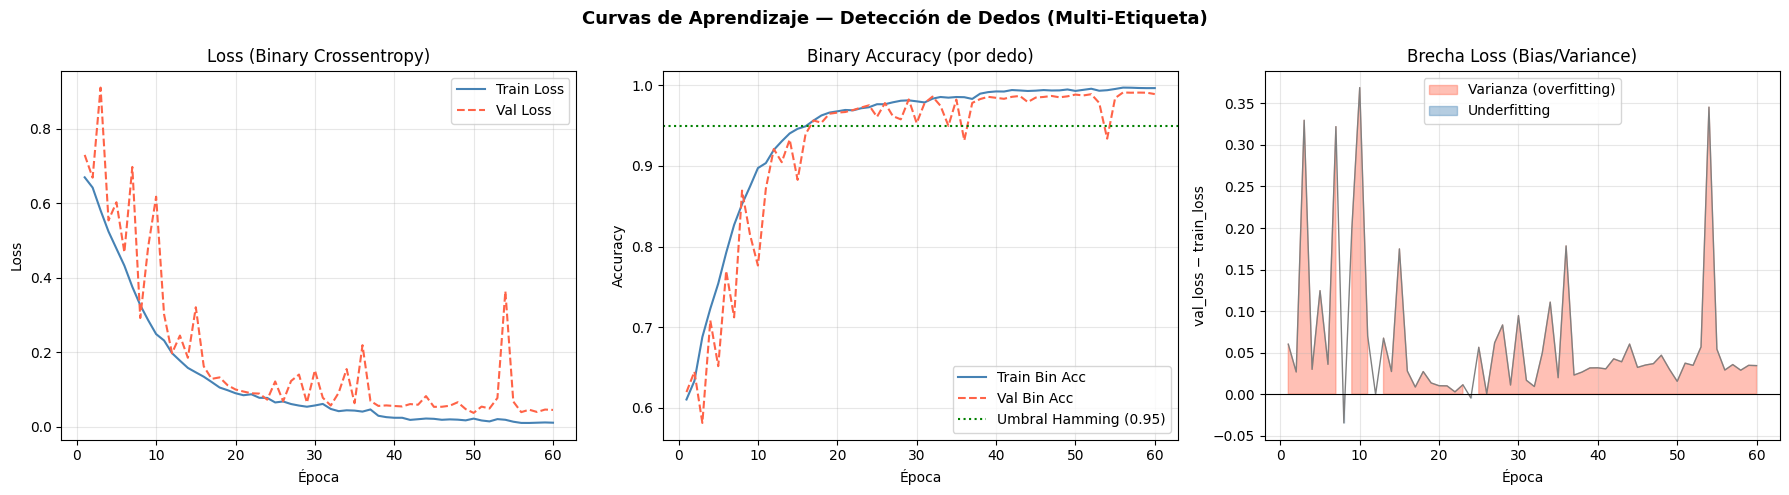


DIAGNÓSTICO BIAS / VARIANCE
Train Loss final : 0.0110
Val   Loss final : 0.0454
Brecha (gap)     : 0.0343

 BALANCE OK: Bias y Variance en rango aceptable.


In [8]:
# ═══════════════════════════════════════════════════════
# CELDA 8: Curvas de aprendizaje + Diagnóstico Bias/Variance
# ═══════════════════════════════════════════════════════
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Curvas de Aprendizaje — Detección de Dedos (Multi-Etiqueta)", fontsize=13, fontweight='bold')

# ── Binary Loss ──
axes[0].plot(epochs_ran, hist['loss'],     label='Train Loss',  color='steelblue')
axes[0].plot(epochs_ran, hist['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
axes[0].set_title('Loss (Binary Crossentropy)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Binary Accuracy ──
acc_key = [k for k in hist.keys() if 'binary_accuracy' in k and 'val' not in k][0]
val_acc_key = 'val_' + acc_key
axes[1].plot(epochs_ran, hist[acc_key],     label='Train Bin Acc', color='steelblue')
axes[1].plot(epochs_ran, hist[val_acc_key], label='Val Bin Acc',   color='tomato', linestyle='--')
axes[1].axhline(0.95, color='green',  linestyle=':', label='Umbral Hamming (0.95)')
axes[1].set_title('Binary Accuracy (por dedo)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Brecha Bias/Variance ──
gap = np.array(hist['val_loss']) - np.array(hist['loss'])
axes[2].fill_between(epochs_ran, gap, 0, where=(gap > 0),
                     alpha=0.4, color='tomato',    label='Varianza (overfitting)')
axes[2].fill_between(epochs_ran, gap, 0, where=(gap < 0),
                     alpha=0.4, color='steelblue', label='Underfitting')
axes[2].plot(epochs_ran, gap, color='gray', linewidth=1)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Brecha Loss (Bias/Variance)')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('val_loss − train_loss')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/curvas_dedos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Diagnóstico automático ──
final_gap = hist['val_loss'][-1] - hist['loss'][-1]
print("\n" + "="*50)
print("DIAGNÓSTICO BIAS / VARIANCE")
print("="*50)
print(f"Train Loss final : {hist['loss'][-1]:.4f}")
print(f"Val   Loss final : {hist['val_loss'][-1]:.4f}")
print(f"Brecha (gap)     : {final_gap:.4f}")

if hist['loss'][-1] > 0.25:
    print("\n  HIGH BIAS (Underfitting): La red no aprende los patrones.")
    print("   → Aumenta capas, filtros o épocas.")
elif final_gap > 0.15:
    print("\n  HIGH VARIANCE (Overfitting): Memoriza el training set.")
    print("   → Aumenta Dropout, usa más augmentation.")
else:
    print("\n BALANCE OK: Bias y Variance en rango aceptable.")

In [9]:
# ═══════════════════════════════════════════════════════
# CELDA 9: Evaluación en Test Set
# ═══════════════════════════════════════════════════════

# ── Predicciones ──
Y_proba_test = model_fingers.predict(test_gen, verbose=0)
Y_pred_test  = (Y_proba_test >= FINGER_THRESHOLD).astype(int)

# Extraer etiquetas reales del generador de forma segura
Y_true_list = []
for i in range(len(test_gen)):
    _, batch_y = test_gen[i]
    Y_true_list.append(batch_y)
Y_true_test = np.vstack(Y_true_list)[:len(Y_pred_test)].astype(int)

# ── Métricas de satisfacción ──
exact_match  = accuracy_score(Y_true_test, Y_pred_test)           # Exact Match Ratio
hamming_acc  = 1 - hamming_loss(Y_true_test, Y_pred_test)         # Hamming Accuracy
macro_f1     = f1_score(Y_true_test, Y_pred_test, average='macro', zero_division=0)

print("="*55)
print("EVALUACIÓN EN TEST SET — Multi-Etiqueta")
print("="*55)
print(f"  Exact Match Ratio   : {exact_match:.4f}  (los 5 dedos correctos)")
print(f"  Hamming Accuracy    : {hamming_acc:.4f}  (por dedo individual)")
print(f"  Macro F1-Score      : {macro_f1:.4f}")

# ── Criterio de satisfacción ──
print()
if exact_match >= THRESHOLD_ROBUST:
    print(f"✅ MODELO ROBUSTO — supera umbral robusto ({THRESHOLD_ROBUST})")
elif exact_match >= THRESHOLD_ACCEPTABLE:
    print(f"🟡 MODELO ACEPTABLE — supera umbral aceptable ({THRESHOLD_ACCEPTABLE})")
else:
    print(f"❌ MODELO INSUFICIENTE — no supera umbral aceptable ({THRESHOLD_ACCEPTABLE})")

# ── Métricas por dedo ──
print("\nMétricas individuales por dedo:")
print(f"{'Dedo':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Accuracy':>10}")
print("-" * 52)
for i, name in enumerate(FINGER_NAMES):
    prec = precision_score(Y_true_test[:, i], Y_pred_test[:, i], zero_division=0)
    rec  = recall_score(Y_true_test[:, i],    Y_pred_test[:, i], zero_division=0)
    f1   = f1_score(Y_true_test[:, i],        Y_pred_test[:, i], zero_division=0)
    acc  = accuracy_score(Y_true_test[:, i],  Y_pred_test[:, i])
    flag = " ⚠️" if f1 < 0.80 else ""
    print(f"{name:<12} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f} {acc:>10.3f}{flag}")

EVALUACIÓN EN TEST SET — Multi-Etiqueta
  Exact Match Ratio   : 0.9815  (los 5 dedos correctos)
  Hamming Accuracy    : 0.9935  (por dedo individual)
  Macro F1-Score      : 0.9927

✅ MODELO ROBUSTO — supera umbral robusto (0.92)

Métricas individuales por dedo:
Dedo          Precision     Recall         F1   Accuracy
----------------------------------------------------
Pulgar            0.994      0.999      0.996      0.995
Índice            0.994      0.994      0.994      0.992
Medio             0.991      0.988      0.989      0.989
Anular            0.990      0.982      0.986      0.992
Meñique           1.000      0.997      0.999      0.999


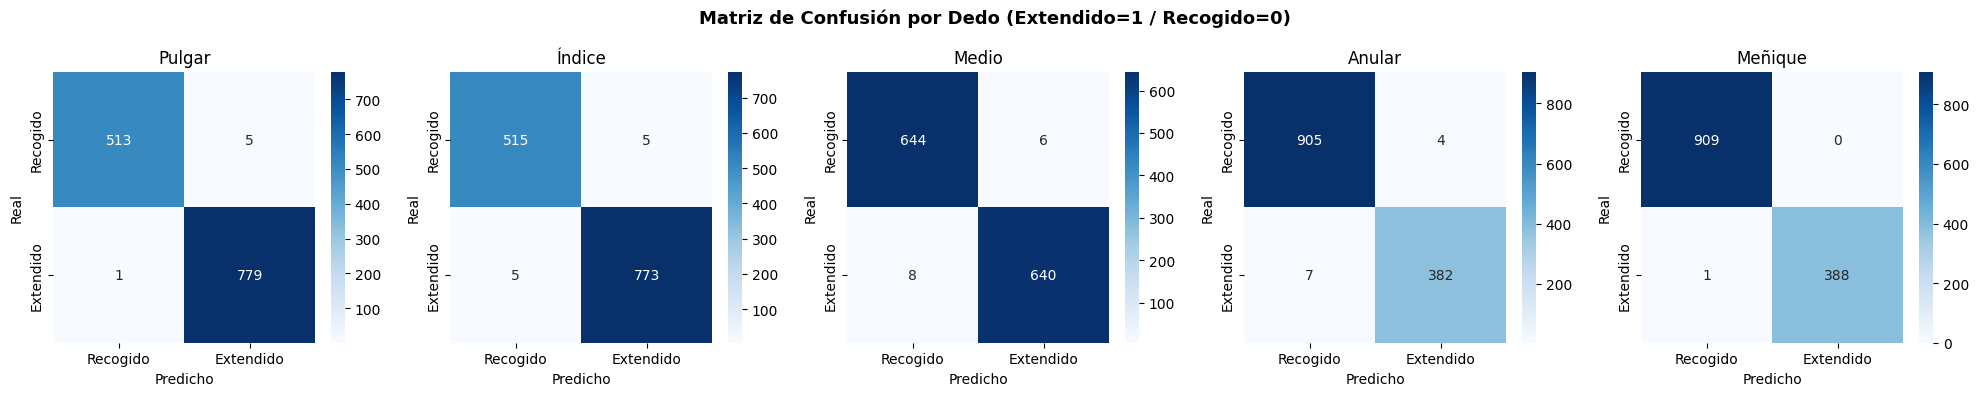

In [12]:
# ═══════════════════════════════════════════════════════
# CELDA 10: Confusion Matrix por cada dedo
# ═══════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Matriz de Confusión por Dedo (Extendido=1 / Recogido=0)",
             fontsize=13, fontweight='bold')

for i, (name, ax) in enumerate(zip(FINGER_NAMES, axes)):
    cm = confusion_matrix(Y_true_test[:, i], Y_pred_test[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Recogido', 'Extendido'],
                yticklabels=['Recogido', 'Extendido'])
    ax.set_title(name)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('/content/confusion_por_dedo.png', dpi=150, bbox_inches='tight')
plt.show()

ANÁLISIS DE ERRORES
Total errores (no exact match): 24 / 1298 (1.8%)
Confianza media en errores     : 0.971
  Errores con 1 dedo(s) mal: 10
  Errores con 2 dedo(s) mal: 11
  Errores con 3 dedo(s) mal: 2
  Errores con 4 dedo(s) mal: 1
  Errores con 5 dedo(s) mal: 0

Tasa de error por dígito:
Dígito       Error Rate   N muestras
-----------------------------------
  0              0.000          130
  1              0.008          130
  2              0.023          129
  3              0.008          130
  4              0.023          129
  5              0.000          130
  6              0.031          130
  7              0.038          130
  8              0.046          130
  9              0.008          130


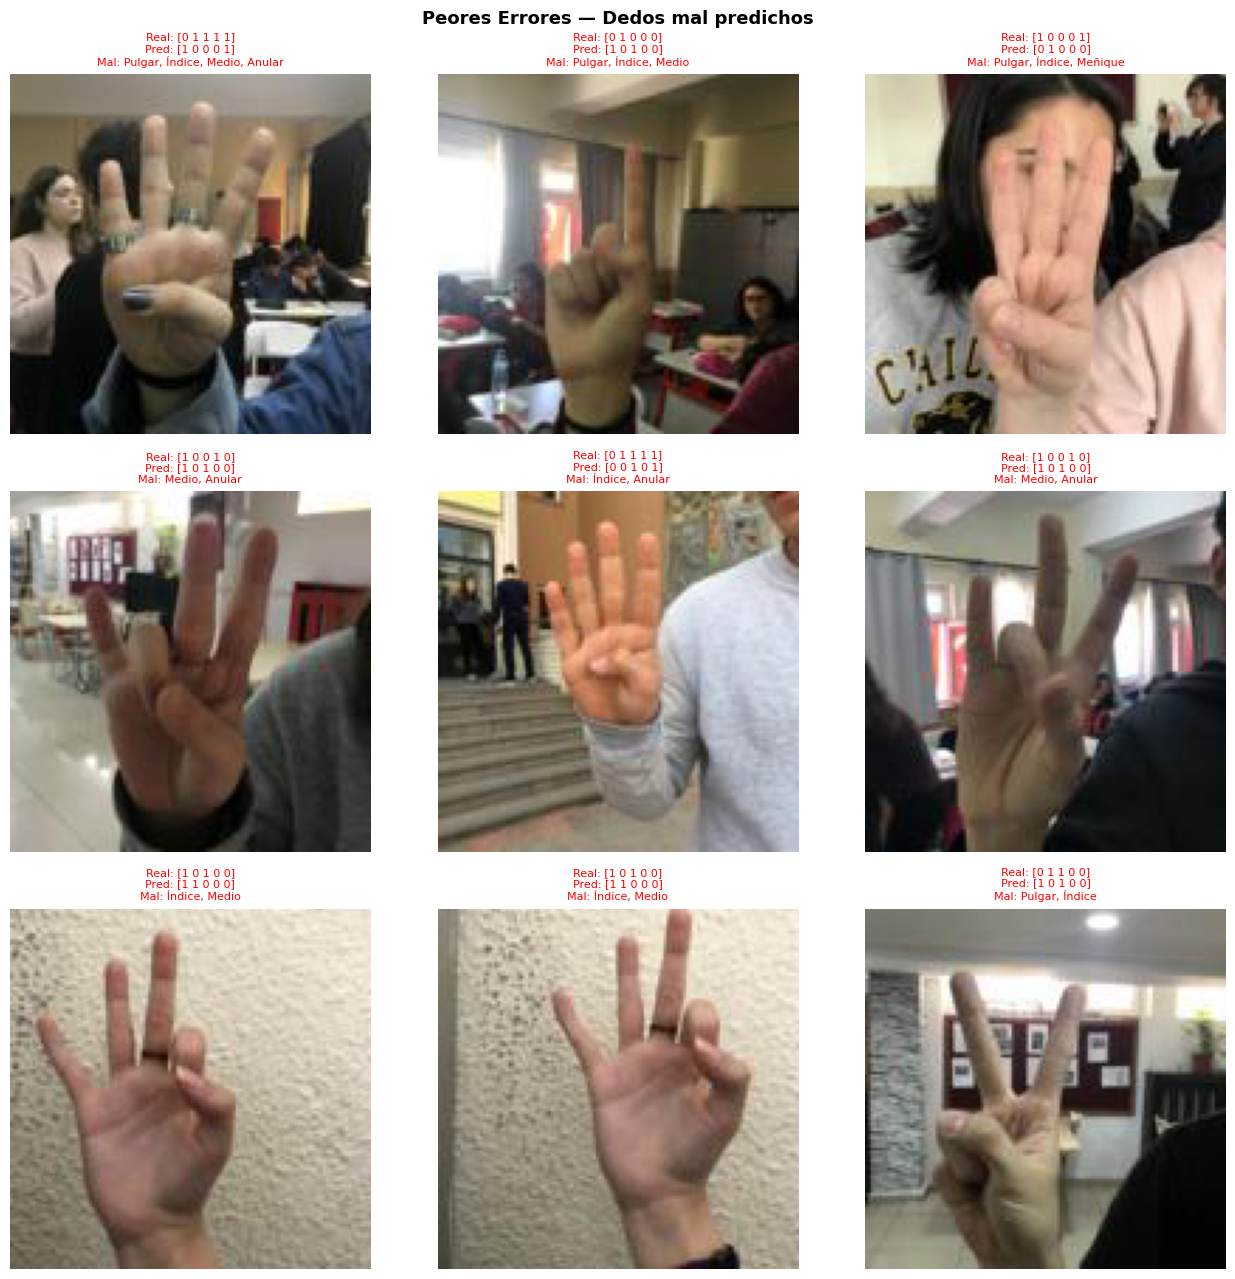

In [11]:
# ═══════════════════════════════════════════════════════
# CELDA 11: Análisis de Errores
# ═══════════════════════════════════════════════════════

# Identificar predicciones incorrectas (no exact match)
errors_mask   = ~(Y_pred_test == Y_true_test).all(axis=1)
error_indices = np.where(errors_mask)[0]

# Confianza máxima en predicciones con error
max_conf_errors = Y_proba_test[error_indices].max(axis=1)

print("="*50)
print("ANÁLISIS DE ERRORES")
print("="*50)
print(f"Total errores (no exact match): {len(error_indices)} / {len(Y_true_test)} "
      f"({100*len(error_indices)/len(Y_true_test):.1f}%)")
print(f"Confianza media en errores     : {max_conf_errors.mean():.3f}")

# Tipo de error: cuántos dedos se equivocaron
n_wrong_fingers = (Y_pred_test[error_indices] != Y_true_test[error_indices]).sum(axis=1)
for n in range(1, 6):
    count = (n_wrong_fingers == n).sum()
    print(f"  Errores con {n} dedo(s) mal: {count}")

# Errores por dígito
print("\nTasa de error por dígito:")
print(f"{'Dígito':<10} {'Error Rate':>12} {'N muestras':>12}")
print("-" * 35)
for d in digit_labels:
    mask_d = (y_test_str == d)
    if mask_d.sum() == 0:
        continue
    err_rate = errors_mask[mask_d].mean()
    flag = " ⚠️" if err_rate > 0.20 else ""
    print(f"  {d:<8} {err_rate:>11.3f} {mask_d.sum():>12}{flag}")

# ── Visualizar 9 peores errores ──
if len(error_indices) > 0:
    n_show = min(9, len(error_indices))
    worst  = error_indices[np.argsort(-n_wrong_fingers)][:n_show]

    fig, axes = plt.subplots(3, 3, figsize=(13, 13))
    fig.suptitle("Peores Errores — Dedos mal predichos", fontsize=13, fontweight='bold')

    for i, err_pos in enumerate(worst):
        real_data_idx = real_idx_test[err_pos]
        img = np.array(X_full[real_data_idx], dtype=np.float32)
        if img.max() > 1.5:
            img /= 255.0
        img_show = img.squeeze() if img.shape[-1] == 1 else img

        true_vec = Y_true_test[err_pos]
        pred_vec = Y_pred_test[err_pos]
        wrong_n  = (true_vec != pred_vec).sum()

        # Mostrar como texto qué dedos están mal
        wrong_fingers = [FINGER_NAMES[j] for j in range(5) if true_vec[j] != pred_vec[j]]
        title_txt = f"Real: {true_vec}\nPred: {pred_vec}\nMal: {', '.join(wrong_fingers)}"

        ax = axes[i // 3][i % 3]
        ax.imshow(img_show, cmap='gray' if img_show.ndim == 2 else None)
        ax.axis('off')
        ax.set_title(title_txt, color='red', fontsize=8)

    plt.tight_layout()
    plt.savefig('/content/errores_dedos.png', dpi=150, bbox_inches='tight')
    plt.show()

In [13]:
# ═══════════════════════════════════════════════════════
# CELDA 12: Resumen Final del Experimento
# ═══════════════════════════════════════════════════════
per_finger_acc = [accuracy_score(Y_true_test[:, i], Y_pred_test[:, i])
                  for i in range(5)]
per_finger_f1  = [f1_score(Y_true_test[:, i], Y_pred_test[:, i], zero_division=0)
                  for i in range(5)]

print("="*58)
print("    RESUMEN FINAL — CNN DETECCIÓN DE DEDOS")
print("="*58)
print(f"  Arquitectura       : CNN 3 bloques Conv + GAP")
print(f"  Tipo de problema   : Multi-etiqueta (5 salidas binarias)")
print(f"  Optimizador        : Adam (lr=1e-3)")
print(f"  Loss (optimiz.)    : {OPTIMIZER_LOSS}")
print(f"  Umbral decisión    : {FINGER_THRESHOLD}")
print(f"  Dígitos            : 0-9 (10 clases ASL)")
print(f"  Train samples      : {len(real_idx_train)}")
print(f"  Test samples       : {len(real_idx_test)}")
print("-"*58)
print(f"  Exact Match Ratio  : {exact_match:.4f}  (umbral: {THRESHOLD_ACCEPTABLE})")
print(f"  Hamming Accuracy   : {hamming_acc:.4f}")
print(f"  Macro F1-Score     : {macro_f1:.4f}")
print(f"  Total errores      : {len(error_indices)} ({100*len(error_indices)/len(Y_true_test):.1f}%)")
print("-"*58)
print("  Accuracy por dedo  :")
for name, acc in zip(FINGER_NAMES, per_finger_acc):
    bar = "█" * int(acc * 20)
    print(f"    {name:<10}: {acc:.3f}  {bar}")
print("-"*58)

gap_final = hist['val_loss'][-1] - hist['loss'][-1]
if abs(gap_final) < 0.1:
    bv_diag = " Bien balanceado"
elif gap_final > 0.1:
    bv_diag = "  Tendencia a overfitting (alta varianza)"
else:
    bv_diag = "  Tendencia a underfitting (alto bias)"

print(f"  Train Loss final   : {hist['loss'][-1]:.4f}")
print(f"  Val   Loss final   : {hist['val_loss'][-1]:.4f}")
print(f"  Bias/Variance      : {bv_diag}")
print("="*58)

    RESUMEN FINAL — CNN DETECCIÓN DE DEDOS
  Arquitectura       : CNN 3 bloques Conv + GAP
  Tipo de problema   : Multi-etiqueta (5 salidas binarias)
  Optimizador        : Adam (lr=1e-3)
  Loss (optimiz.)    : binary_crossentropy
  Umbral decisión    : 0.5
  Dígitos            : 0-9 (10 clases ASL)
  Train samples      : 6058
  Test samples       : 1298
----------------------------------------------------------
  Exact Match Ratio  : 0.9815  (umbral: 0.85)
  Hamming Accuracy   : 0.9935
  Macro F1-Score     : 0.9927
  Total errores      : 24 (1.8%)
----------------------------------------------------------
  Accuracy por dedo  :
    Pulgar    : 0.995  ███████████████████
    Índice    : 0.992  ███████████████████
    Medio     : 0.989  ███████████████████
    Anular    : 0.992  ███████████████████
    Meñique   : 0.999  ███████████████████
----------------------------------------------------------
  Train Loss final   : 0.0110
  Val   Loss final   : 0.0454
  Bias/Variance      : ✅ Bien